# Evidence Retrieval Experiment Framework

This notebook acts as the central experiment framework for the dissertation.

It does not perform exploratory analysis of AVeriTeC; this is covered in the separate data inspection notebook. Instead, this notebook:

1. defines the experimental and reproducibility settings;
2. loads the prepared claims and candidate evidence collection;
3. executes each retrieval configuration through a common interface;
4. evaluates the resulting rankings using the same metrics;
5. records the configuration and environment associated with each run;

Retrieval implementations are contained in separate Python modules so that the experimental procedure remains consistent across methods.

## 1. Setup and Imports

In [51]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from datetime import datetime, timezone

import os
import sys
import json
import time
import random
import psutil
import threading
import subprocess
from time import perf_counter
import matplotlib.pyplot as plt

import nltk
import torch
import numpy as np
import pandas as pd
import transformers
import sentence_transformers


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1.1 Resource Monitor Utils

In [53]:
class ResourceMonitor:
    def __init__(self, interval=1.0):
        self.interval = interval
        self.process = psutil.Process(os.getpid())
        self.samples = []
        self.running = False
        self.thread = None

    def _sample(self):
        self.process.cpu_percent(None)

        start = time.perf_counter()

        while self.running:
            elapsed = time.perf_counter() - start
            cpu = (self.process.cpu_percent(None) / psutil.cpu_count())
            ram_gb = (self.process.memory_info().rss / 1024**3)
            gpu_gb = None

            if torch.cuda.is_available():
                gpu_gb = (torch.cuda.memory_allocated() / 1024**3)

            self.samples.append({"time": elapsed, "cpu": cpu, "ram_gb": ram_gb, "gpu_gb": gpu_gb})
            time.sleep(self.interval)

    def start(self):
        self.samples = []
        self.running = True
        self.thread = threading.Thread(target=self._sample, daemon=True)
        self.thread.start()

    def stop(self):
        self.running = False

        if self.thread is not None:
            self.thread.join()

        return pd.DataFrame(self.samples)


def plot_resources(data, title):
    fig, ax = plt.subplots()

    ax.plot(data["time"], data["cpu"], label="CPU utilisation (%)")

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("CPU utilisation (%)")
    ax.set_title(title)
    ax.legend()

    plt.show()

    fig, ax = plt.subplots()

    ax.plot(data["time"], data["ram_gb"], label="RAM (GB)")

    if data["gpu_gb"].notna().any():
        ax.plot(data["time"], data["gpu_gb"], label="GPU VRAM (GB)")

    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Memory (GB)")
    ax.set_title(title)
    ax.legend()

    plt.show()

In [26]:
from fact_verification.data import CandidateStore, load_claims
from fact_verification.retrieval.bm25 import BM25Config, BM25Retriever
from fact_verification.retrieval.dpr import DPRConfig, DPRRetriever
from fact_verification.retrieval.hybrid import HybridConfig, HybridRetriever


from fact_verification.reranking.cross_encoder import CrossEncoderConfig, CrossEncoderReranker

from fact_verification.evaluation import evaluate_retrieval

## 2. Experimental Configuration and Reproducibility

All variables capable of changing the experimental outcome are defined here.
Values should not be changed inside individual retrieval sections.

### 2.1. Main Experiment Configuration

In [27]:
EXPERIMENT = {
    "experiment_name": "initial_retriever_comparison",
    "seed": 67,

    "dataset": {
        "name": "AVeriTeC",
        "split": "dev",
        "revision": None,
        "root": os.environ.get("AVERITEC_ROOT"),
    },

    "candidates": {
        "retrieval_unit": "sentence",
        "chunk_size": None,
        "chunk_overlap": None,
    },

    "retrieval": {
        "retrieve_k": 100,
    },

    "evaluation": {
        "cutoffs": [1, 5, 10, 20, 50, 100],
    },

    "bm25": {
        "k1": 1.5,
        "b": 0.75,
        "epsilon": 0.25,
        "lowercase": False,
    },

    "dpr": {
        "question_model":
            "facebook/dpr-question_encoder-multiset-base",
        "context_model":
            "facebook/dpr-ctx_encoder-multiset-base",

        "question_revision": None,
        "context_revision": None,

        "batch_size": 32,
        "max_length": 512,
        "use_title": False,
        "device": "cuda" if torch.cuda.is_available() else "cpu",
    },

    "hybrid": {
        "method": "rrf",
        "fusion_depth": 100,
        "rrf_constant": 60,
        "alpha": 0.5,
    },

    "reranker": {
        "model_name":
            "cross-encoder/ms-marco-MiniLM-L6-v2",
        "revision": None,
        "batch_size": 32,
        "candidate_k": 100,
        "output_k": 20,
        "device": "cuda" if torch.cuda.is_available() else "cpu",
    },
}
DATA_ROOT = EXPERIMENT["dataset"]["root"]

if DATA_ROOT is None:
    raise RuntimeError(
        "AVERITEC_ROOT is not set. "
        "Set it to the root directory of the AVeriTeC data."
    )

DATA_ROOT = Path(DATA_ROOT)



### 2.2. Resolve configuration / paths

In [28]:
DATA_ROOT_VALUE = EXPERIMENT["dataset"]["root"]

if DATA_ROOT_VALUE is None:
    raise RuntimeError("AVERITEC_ROOT is not set. Set the environment variable to the root of the AVeriTeC dataset.")

DATA_ROOT = Path(DATA_ROOT_VALUE).expanduser().resolve()

if not DATA_ROOT.exists():
    raise FileNotFoundError(f"AVeriTeC data root does not exist: {DATA_ROOT}")

print(f"Data root: {DATA_ROOT}")

Data root: C:\Users\conno_i4oarur.MACPEPINO\OneDrive\Documents\GitHub\AutomatedFactVerification_RetrieverComparison\.local_data\averitec\2ca9dee23a2a


### 2.3. Fix random seeds

In [29]:
SEED = EXPERIMENT["seed"]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

### 2.4. Capture environment 

In [30]:
def get_git_commit():
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "HEAD"],
            text=True
        ).strip()
    except Exception:
        return None


ENVIRONMENT = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "python_version": sys.version,
    "torch_version": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_version": torch.version.cuda,
    "gpu": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else None
    ),
    "git_commit": get_git_commit(),
    "transformers_version": transformers.__version__,
    "sentence_transformers_version":sentence_transformers.__version__,
    "nltk_version": nltk.__version__,
}
pd.Series(ENVIRONMENT)

# NOTE: list not exhaustive, this is early expectations of what would be needed, should be updated later.

timestamp_utc                                     2026-08-13T15:46:49.089557+00:00
python_version                   3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:...
torch_version                                                           2.13.0+cpu
cuda_available                                                               False
cuda_version                                                                  None
gpu                                                                           None
git_commit                                62864bc6381096c854ef972eabd5361beec52752
transformers_version                                                        5.15.0
sentence_transformers_version                                                5.7.0
nltk_version                                                                3.10.2
dtype: object

## 3. Load experimental data
Dataset structure and annotation characteristics are explored separately in
`01_averitec_data_inspection.ipynb`.  (NOTE: or whatever its called later)

Only the processed inputs required for retrieval are loaded here.

### 3.1. Initialise Claims and Candidate Store

In [37]:
claims = load_claims(root=DATA_ROOT, split=EXPERIMENT["dataset"]["split"])

candidate_store = CandidateStore(root=DATA_ROOT, split=EXPERIMENT["dataset"]["split"], retrieval_unit=EXPERIMENT["candidates"]["retrieval_unit"], chunk_size=EXPERIMENT["candidates"]["chunk_size"], chunk_overlap=EXPERIMENT["candidates"]["chunk_overlap"])
print(f"Claims loaded: {len(claims):,}")
print(f"Knowledge-store claims: {len(candidate_store):,}")
print(f"Retrieval unit: {candidate_store.retrieval_unit}")
print(f"Knowledge store: {candidate_store.directory}")


Claims loaded: 500
Knowledge-store claims: 500
Retrieval unit: sentence
Knowledge store: C:\Users\conno_i4oarur.MACPEPINO\OneDrive\Documents\GitHub\AutomatedFactVerification_RetrieverComparison\.local_data\averitec\2ca9dee23a2a\knowledge_store\dev\output_dev


### 3.2. Candidate GTeneration Sanity Check

In [38]:
EXAMPLE_CLAIM_ID = claims.iloc[0]["claim_id"]

example_claim = claims.loc[claims["claim_id"] == EXAMPLE_CLAIM_ID, "claim"].iloc[0]
example_candidates = candidate_store.load_claim(EXAMPLE_CLAIM_ID)

print(f"Claim ID: {EXAMPLE_CLAIM_ID}")
print(f"Claim: {example_claim}")
print(f"Candidates generated: {len(example_candidates):,}")

display(example_candidates[["candidate_id", "source_url", "text", "sentence_start", "sentence_end"]].head(10))

Claim ID: 0
Claim: In a letter to Steve Jobs, Sean Connery refused to appear in an apple commercial.
Candidates generated: 534,488


,candidate_id,source_url,text,sentence_start,sentence_end
0,0:0:0,https://web.archive.org/web/20201129141238/htt...,"San Francisco, CA — It’s easy to appreciate iM...",0,0
1,0:0:1,https://web.archive.org/web/20201129141238/htt...,"In fact, Apple’s concerns over the brand-new c...",1,1
2,0:0:2,https://web.archive.org/web/20201129141238/htt...,The surprising story comes to light in iMacula...,2,2
3,0:0:3,https://web.archive.org/web/20201129141238/htt...,"As Ms. Woods spins the tale, it was just weeks...",3,3
4,0:0:4,https://web.archive.org/web/20201129141238/htt...,"Steve Jobs, a lifelong fan of James Bond (he’d...",4,4
5,0:0:5,https://web.archive.org/web/20201129141238/htt...,"“The ad was of dubious quality, clearly not on...",5,5
6,0:0:6,https://web.archive.org/web/20201129141238/htt...,"Though Steve had a thing for Sean Connery, the...",6,6
7,0:0:7,https://web.archive.org/web/20201129141238/htt...,Connery’s final rejection was accompanied by a...,7,7
8,0:0:8,https://web.archive.org/web/20201129141238/htt...,"Needless to say, iMac managed to “survive” wit...",8,8
9,0:0:9,https://web.archive.org/web/20201129141238/htt...,iMaculate Conception reveals a number of other...,9,9


In [39]:
assert not example_candidates.empty
assert example_candidates["candidate_id"].is_unique
assert example_candidates["text"].notna().all()

required_columns = {"claim_id", "candidate_id", "source_url", "text"}
missing = required_columns - set(example_candidates.columns)

assert not missing, (f"Candidate store is missing required fields: {sorted(missing)}")

## 4. Initialise Experimental Models

### 4.1. Initialise BM25 Retriever

In [42]:
bm25 = BM25Retriever(config=BM25Config(**EXPERIMENT["bm25"]))

print("BM25 retriever initialised.")

BM25 retriever initialised.


### 4.2. Initialise DPR

In [43]:
dpr = DPRRetriever(config=DPRConfig(**EXPERIMENT["dpr"]))

print("DPR initialised.")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 41311.83it/s]
[transformers] DPRQuestionEncoder LOAD REPORT from: facebook/dpr-question_encoder-multiset-base
Key                                             | Status     |  | 
------------------------------------------------+------------+--+-
question_encoder.bert_model.pooler.dense.weight | UNEXPECTED |  | 
question_encoder.bert_model.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 197/197 [00:00<00:00, 30412.52it/s]
[transformers] DPRContextEncoder LOAD REPORT from: facebook/dpr-ctx_encoder-multiset-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
ctx_encoder.bert_model.pooler.dense.bias   | UNEXPECTED |  | 
ctx_encoder.bert_model.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored 

DPR initialised.


### 4.3. Initialise Hybrid Retriever
This section essentially just consumes the existing results, opposed to regenerating the experiment results for both BM25 and DPR

In [44]:
hybrid = HybridRetriever(lexical_retriever=bm25, dense_retriever=dpr, config=HybridConfig(**EXPERIMENT["hybrid"]))

print("Hybrid retriever initialised.")

Hybrid retriever initialised.


### 4.4. Initialse Cross-Encoder Reranker
As with the hybrid retrieval, the reranker should consume candidate results from one of the first-stage systems

In [45]:
reranker_config = EXPERIMENT["reranker"]

cross_encoder = CrossEncoderReranker(
    config=CrossEncoderConfig(
        model_name=reranker_config["model_name"],
        revision=reranker_config["revision"],
        batch_size=reranker_config["batch_size"],
        device=reranker_config["device"],
    )
)

print("Cross-encoder reranker initialised.")

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 6257.40it/s]


Cross-encoder reranker initialised.


## 5. Retrieval Experiments
Each retrieval method is executed using the same claims, candidate store and
retrieval depth defined in the experimental configuration.

### 5.1. Run BM25 

BM25Retriever: 100%|██████████| 500/500 [4:59:43<00:00, 35.97s/claim]  


BM25 results: 50,000
Runtime: 17982.10s


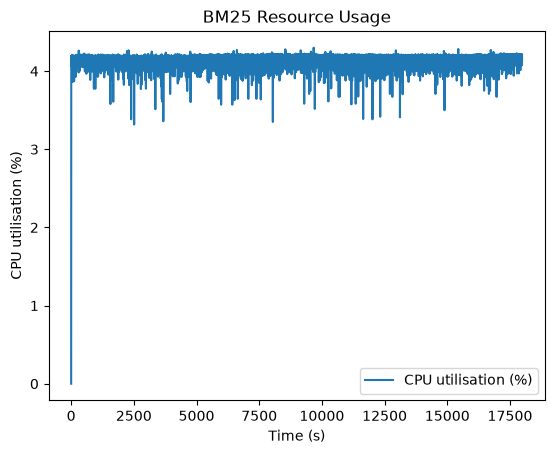

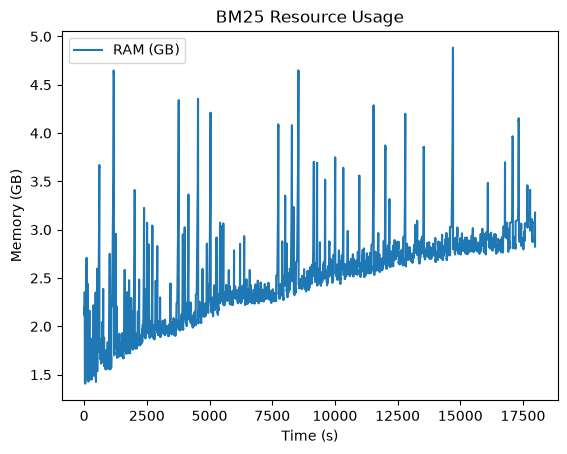

In [54]:
RUNTIMES = {}
RESOURCE_USAGE = {}

monitor = ResourceMonitor()
monitor.start()

start = perf_counter()

bm25_results = bm25.retrieve_batch(claims=claims, candidates=candidate_store, k=EXPERIMENT["retrieval"]["retrieve_k"])

RUNTIMES["bm25"] = perf_counter() - start
RESOURCE_USAGE["bm25"] = monitor.stop()

print(f"BM25 results: {len(bm25_results):,}")
print(f"Runtime: {RUNTIMES['bm25']:.2f}s")

plot_resources(RESOURCE_USAGE["bm25"], "BM25 Resource Usage")

### 5.2. Run DPR

In [ ]:
monitor = ResourceMonitor()
monitor.start()

start = perf_counter()

dpr_results = dpr.retrieve_batch(claims=claims, candidates=candidate_store, k=EXPERIMENT["retrieval"]["retrieve_k"])

RUNTIMES["dpr"] = perf_counter() - start
RESOURCE_USAGE["dpr"] = monitor.stop()

print(f"DPR results: {len(dpr_results):,}")
print(f"Runtime: {RUNTIMES['dpr']:.2f}s")

display(dpr_results.head())

plot_resources(RESOURCE_USAGE["dpr"], "DPR Resource Usage")

### 5.3. Run Hybrid Fusion

In [ ]:
monitor = ResourceMonitor()
monitor.start()

start = perf_counter()

hybrid_results = hybrid.fuse_batch(lexical_results=bm25_results, dense_results=dpr_results, k=EXPERIMENT["retrieval"]["retrieve_k"])

RUNTIMES["hybrid"] = perf_counter() - start
RESOURCE_USAGE["hybrid"] = monitor.stop()

print(f"Hybrid results: {len(hybrid_results):,}")
print(f"Runtime: {RUNTIMES['hybrid']:.2f}s")

display(hybrid_results.head())

plot_resources(RESOURCE_USAGE["hybrid"], "Hybrid Fusion Resource Usage")

### 5.4. Run Cross-Encoder Reranking

In [ ]:
monitor = ResourceMonitor()
monitor.start()

start = perf_counter()

reranked_results = cross_encoder.rerank_batch(claims=claims, candidates=hybrid_results, candidate_k=EXPERIMENT["reranker"]["candidate_k"], output_k=EXPERIMENT["reranker"]["output_k"])

RUNTIMES["cross_encoder"] = perf_counter() - start
RESOURCE_USAGE["cross_encoder"] = monitor.stop()

print(f"Reranked results: {len(reranked_results):,}")
print(f"Runtime: {RUNTIMES['cross_encoder']:.2f}s")

display(reranked_results.head())

plot_resources(RESOURCE_USAGE["cross_encoder"], "Cross-Encoder Resource Usage")